# Build Event Catalog and Resilience Stress/Training Set - Marshfield, MA

Build the 2,500-row Probability Catalog and 500-row flood-forcing stress set for SFINCS depth profiles that drive risk and DNMG contingency-operation studies.

> **Stage Contract**
>
> Requires: collected source artifacts from 02_collect_sources.ipynb
>
> Produces: event catalog CSVs and surge_event_members.nc
>
> Next: 04/a_build_waves.ipynb for wave-coupled production base

In [1]:
# Load local packages and this Location Workspace.
import os
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
workspace_candidates = [p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()]
location_name = os.environ.get("FLOOD_RM_LOCATION", "marshfield")
config_yaml = Path(os.environ["FLOOD_RM_LOCATION_CONFIG"]).expanduser() if "FLOOD_RM_LOCATION_CONFIG" in os.environ else workspace_candidates[0] / "config.yaml" if workspace_candidates else repo_root / "locations" / location_name / "config.yaml"

# Imports + load runtime config.
from importlib import import_module
import json
import numpy as np
import pandas as pd
from IPython.display import display

from design_events.config import load_runtime
from design_events.readiness import source_inventory_frame
from design_events import plotting as P

catalog = import_module("design_events.fit_history.peaks")
events = import_module("design_events.build_events.hydrographs")
sampler = import_module("design_events.build_events.sample_peaks")
build_catalog = catalog.build_catalog
fit_historical_peaks = catalog.fit_historical_peaks
load_hourly_waterlevel = catalog.load_hourly_waterlevel
build_surge_event_artifacts = events.build_surge_event_artifacts
write_event_artifacts = events.write_event_artifacts
build_sampled_peaks = sampler.build_sampled_peaks
from design_events.fit_history.return_curve import marginal_params_frame, marginal_rps_frame
from design_events.build_events.event_catalog import build_event_catalog, rebuild_forcing_pairing
from design_events.build_events.event_selection import select_resilience_stress_training_set
from design_events.build_events.plan import build_event_catalog_plan
from sfincs_runs.scenarios.scenarios import build_event_timeseries, read_design_inputs

config, paths = load_runtime(config_yaml)
pd.Series({
    "waterlevel_csv": str(paths["waterlevel_csv"]),
    "pot_threshold_quantile": config["extremes"]["pot"]["threshold_quantile"],
    "pot_min_peak_distance_hours": config["extremes"]["pot"]["min_peak_distance_hours"],
    "hybrid_splice_quantile": config["sampling"]["hybrid_splice_quantile"],
    "target_event_count": config["events"]["target_event_count"],
    "return_period_max_years": config["sampling"]["return_period_max_years"],
    "stress_training_target_count": config["resilience_stress_training"]["target_event_count"],
    "nearest_pool_size": config["template_assignment"]["nearest_pool_size"],
    "tail_morph_max_factor": config["design_events"]["tail_morph_max_factor"],
})


waterlevel_csv                  /home/grahamhults/projects/Flood-RM/locations/...
pot_threshold_quantile                                                       0.98
pot_min_peak_distance_hours                                                    72
hybrid_splice_quantile                                                       0.95
target_event_count                                                           2500
return_period_max_years                                                     500.0
stress_training_target_count                                                  500
nearest_pool_size                                                              75
tail_morph_max_factor                                                         1.3
dtype: object

## Stage 1 — Source inventory

Start with the driver sources before fitting anything. This is the ADR-0008
front door: every catalog row must trace to a source record, a member table,
and an explicit pairing policy.


In [2]:
source_inventory = source_inventory_frame(config, paths)
display(source_inventory)


,driver,source,role,pairing_policy,status
0,coastal_water_level,CORA,coastal event-index marginal and hydrograph te...,event_index,complete
1,coastal_waves,ERA5 SnapWave boundary,wave forcing from the same historical coastal ...,same_historical_analog,complete
2,rainfall,Direct AORC SST,stochastic storm transposition rainfall members,seasonal_window_permutation,complete
3,soil_moisture,NWM retrospective,antecedent hydrologic state for the paired rai...,antecedent_to_forcing,complete
4,streamflow,not used,Marshfield coastal SFINCS grid has no meaningf...,not_required,not_required


## Stage 2 — Driver libraries and marginal evidence

Start with the driver evidence, not with a flood map. CORA supplies the coastal
water-level frequency axis used for Coastal Driver Return Period labels and
same-analog wave timing. Direct AORC SST supplies rainfall members. NWM supplies
antecedent wetness. ERA5/SnapWave metadata stays tied to the same historical
coastal analog as the CORA template. The catalog is therefore driver-first and
pairing-explicit, not a univariate flood model.


### 2.1 Driver member libraries

Read the non-coastal driver member tables before fitting the coastal marginal.
This makes the story explicit: the coastal return period is one driver axis,
while rainfall-heavy SST members and wet antecedent states remain available for
compound-event selection and SFINCS stress/training.


,driver,source,status,member_rows
0,coastal water level,CORA,complete,NaN
1,rainfall,Direct AORC SST,complete,440.0
2,antecedent soil moisture,NWM retrospective,complete,2566240.0
3,coastal waves,ERA5/SnapWave same coastal analog,complete,NaN


,member_id,source,member_file,storm_start,storm_end,duration_hours,rank,annual_rank,mean_precip_mm,max_precip_mm,...,potential_method,centroid_lon,centroid_lat,historical_centroid_lon,historical_centroid_lat,transposed_centroid_lon,transposed_centroid_lat,transposition_offset_lon,transposition_offset_lat,transposition_region_id
0,rainfall_marshfield_72h_rank0001,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2006-05-13T06:00:00,2006-05-16T06:00:00,72,1,1,297.733933,314.900005,...,moving_footprint_max_mean,-70.844033,42.815754,-71.036200,42.195857,-70.844033,42.815754,0.192167,0.619897,east-atlantic-marshfield
1,rainfall_marshfield_72h_rank0002,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1996-10-19T12:00:00,1996-10-22T12:00:00,72,2,1,240.052682,254.600004,...,moving_footprint_max_mean,-70.910697,42.815754,-71.072850,42.103122,-70.910697,42.815754,0.162153,0.712632,east-atlantic-marshfield
2,rainfall_marshfield_72h_rank0003,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2010-03-13T06:00:00,2010-03-16T06:00:00,72,3,1,224.723218,228.800003,...,moving_footprint_max_mean,-70.977361,42.682426,-71.109667,42.092021,-70.977361,42.682426,0.132306,0.590405,east-atlantic-marshfield
3,rainfall_marshfield_72h_rank0004,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2011-08-25T18:00:00,2011-08-28T18:00:00,72,4,1,217.901789,251.600004,...,moving_footprint_max_mean,-71.644001,42.115782,-71.370290,42.202351,-71.644001,42.115782,-0.273711,-0.086569,east-atlantic-marshfield
4,rainfall_marshfield_72h_rank0005,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2005-10-13T00:00:00,2005-10-16T00:00:00,72,5,1,217.861610,228.100003,...,moving_footprint_max_mean,-71.344013,41.682466,-71.181427,41.967042,-71.344013,41.682466,-0.162586,-0.284576,east-atlantic-marshfield


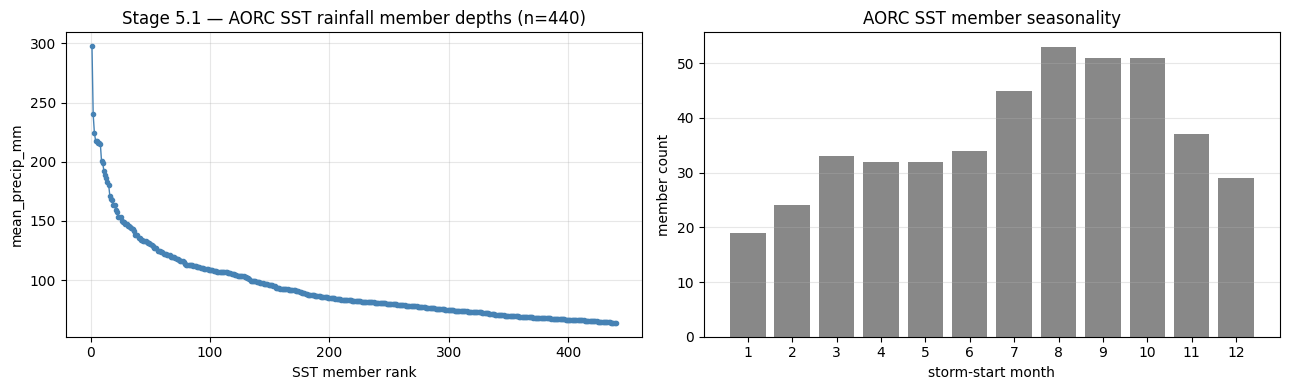

In [3]:
rainfall_members = pd.read_csv(paths["aorc_sst_rainfall_members_csv"])
soil_moisture_members = pd.read_csv(paths["nwm_soil_moisture_csv"])

status_by_driver = source_inventory.set_index("driver")["status"].to_dict()
driver_library_summary = pd.DataFrame([
    {"driver": "coastal water level", "source": "CORA", "status": status_by_driver.get("coastal_water_level")},
    {"driver": "rainfall", "source": "Direct AORC SST", "status": status_by_driver.get("rainfall"), "member_rows": len(rainfall_members)},
    {"driver": "antecedent soil moisture", "source": "NWM retrospective", "status": status_by_driver.get("soil_moisture"), "member_rows": len(soil_moisture_members)},
    {"driver": "coastal waves", "source": "ERA5/SnapWave same coastal analog", "status": status_by_driver.get("coastal_waves")},
])
display(driver_library_summary)
P.plot_rainfall_member_distribution(rainfall_members);
rainfall_members.head(5)


### 2.2 Coastal water-level marginal evidence

CORA is the event-index marginal for the coastal driver. It defines the severity
axis, benchmark return-period labels, coastal target-peak sampling, hydrograph
templates, and the historical coastal analog used for wave timing.


### 2.2.1 Raw CORA hourly water level


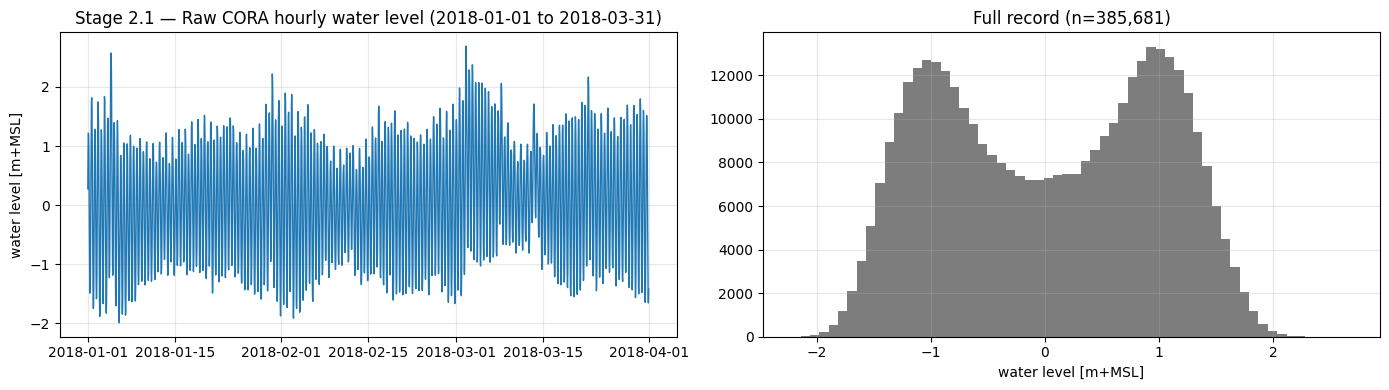

In [4]:
waterlevel = load_hourly_waterlevel(paths["waterlevel_csv"]).dropna().sort_index()
P.plot_raw_waterlevel(waterlevel);


### 2.2.2 Fit the coastal POT marginal

`design_events.fit_history` detrends the hourly record to a reference epoch,
extracts peaks-over-threshold, AIC-selects between Exp/GPD, bootstraps the
return-period curve, and runs a stationarity diagnostic.


In [5]:
historical_peaks, marginal, fit_rps, detrend_meta = fit_historical_peaks(config, waterlevel)
catalog_artifacts = build_catalog(config, paths)
pot_q = config["extremes"]["pot"]["threshold_quantile"]
threshold_m = float(waterlevel.quantile(pot_q))
display(marginal_params_frame(marginal, detrend_meta).T.rename(columns={"h": "value"}))
display(marginal_rps_frame(marginal, fit_rps).round(4))


[detrend] applied boundary_cora_annual_mean slope = +4.17 mm/yr, reference epoch = 2000.0


,value
dist,exp
shape,0.0
loc,1.614073
scale,0.175152
extremes_method,pot
extremes_rate,31.2
threshold_quantile,0.98
peak_count,1404
detrend_applied,True
detrend_slope_m_per_year,0.004169


,h
rps,
1.1,2.2334
2.0,2.3381
5.0,2.4986
10.0,2.6200
25.0,2.7805
50.0,2.9019
100.0,3.0233
250.0,3.1838
500.0,3.3052


### 2.2.3 Detrending the hourly record (linear MSL trend)


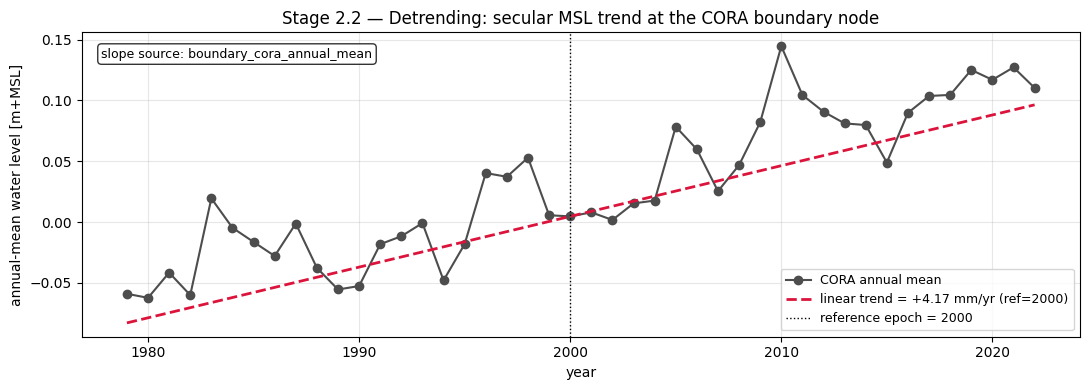

In [6]:
P.plot_detrending(waterlevel, detrend_meta);


### 2.2.4 Peaks-over-threshold extraction


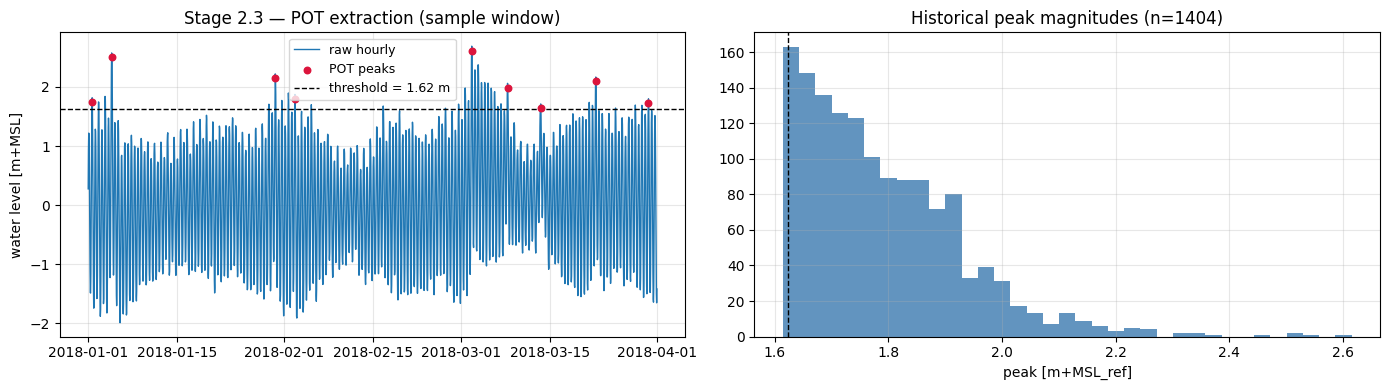

In [7]:
P.plot_pot_extraction(waterlevel, historical_peaks, threshold_m);


### 2.2.5 AIC model selection (Exp vs GPD)


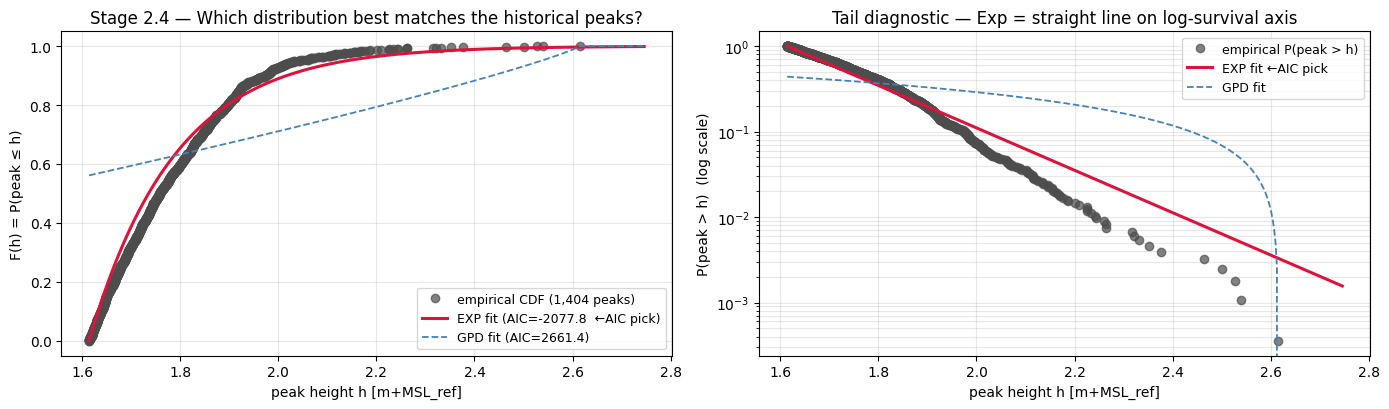

In [8]:
P.plot_aic_model_selection(historical_peaks, marginal);


### 2.2.6 Return-period curve with bootstrap CI


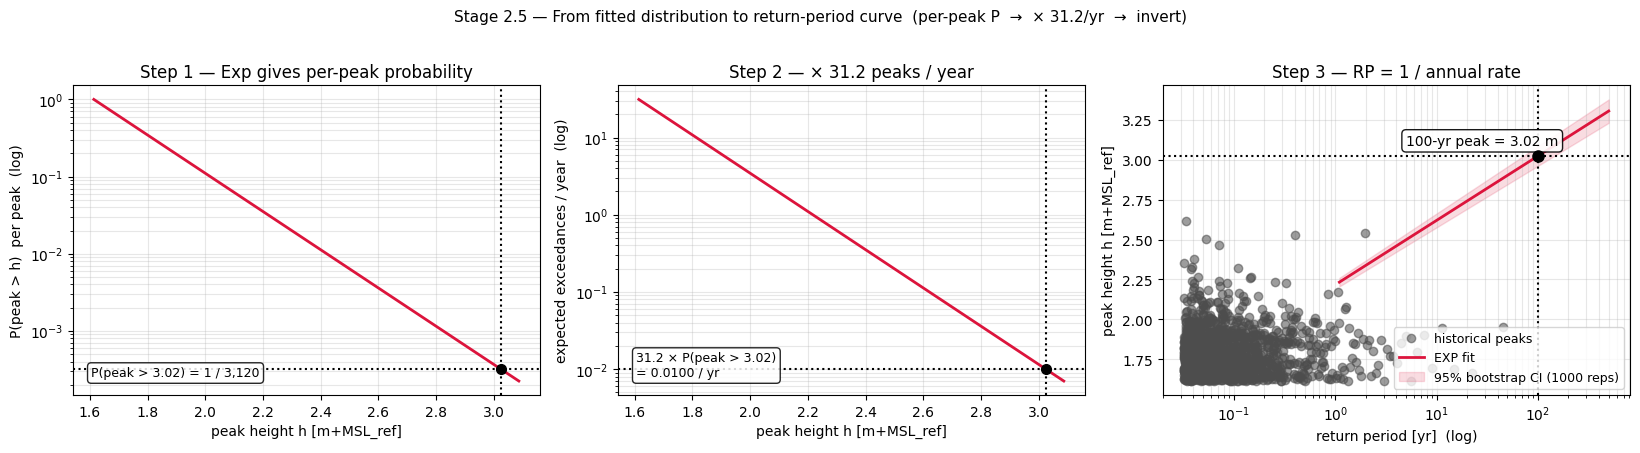

In [9]:
P.plot_return_curve_with_ci(historical_peaks, marginal, catalog_artifacts['bootstrap'], rps=fit_rps);


### 2.2.7 Stationarity diagnostic on selected peaks


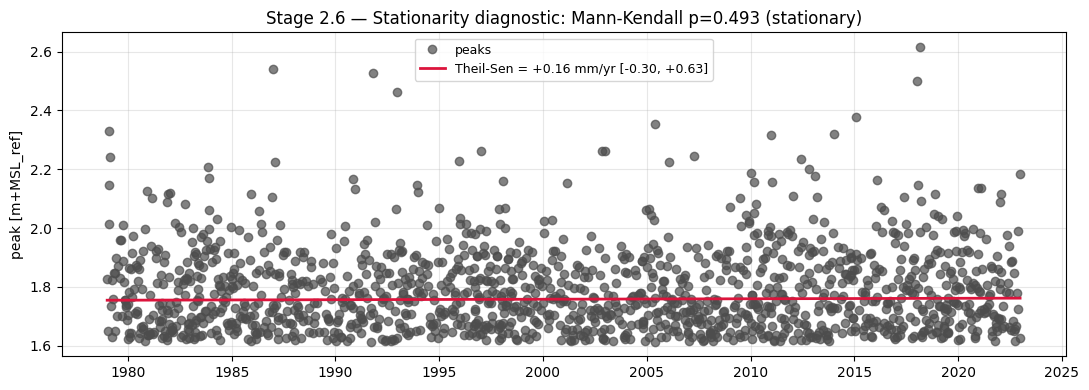

In [10]:
P.plot_stationarity(historical_peaks, catalog_artifacts['stationarity']);


## Stage 3 — Coastal-driver sampling and benchmark design slices

Sample 2,500 synthetic coastal-driver peaks from the fitted marginal, with an
empirical body plus a tail-enriched proposal up to the configured 500-year
coastal-driver ceiling. `sample_rp_years` is a Coastal Driver Return Period,
not a flood return period. The standard 10%, 2%, 1%, and 0.2% annual-chance
benchmarks correspond to 10-, 50-, 100-, and 500-year coastal-driver slices.
The sampler records `sampling_weight` for proposal enrichment and
`probability_weight` for probability-weighted summaries after response
evaluation.


,benchmark_return_period_years,annual_chance_label,event_id,sample_rp_years,severity_band,probability_weight
0,10,10% annual chance,evt_0278,10.01,significant,0.000087
1,50,2% annual chance,evt_0668,49.68,significant,0.000018
2,100,1% annual chance,evt_2456,100.47,extreme,0.000009
3,500,0.2% annual chance,evt_0072,495.84,extreme,0.000002


,event_id,peak_m,sample_rp_years,sampling_region,sampling_weight,probability_weight,severity_band
0,evt_0001,1.881923,0.147906,body,1.1875,0.000475,mild
1,evt_0002,1.671398,0.044461,body,1.1875,0.000475,mild
2,evt_0003,2.575918,7.776219,tail,0.2500,0.000112,common
3,evt_0004,1.990146,0.274365,body,1.1875,0.000475,mild
4,evt_0005,1.869963,0.138144,body,1.1875,0.000475,mild


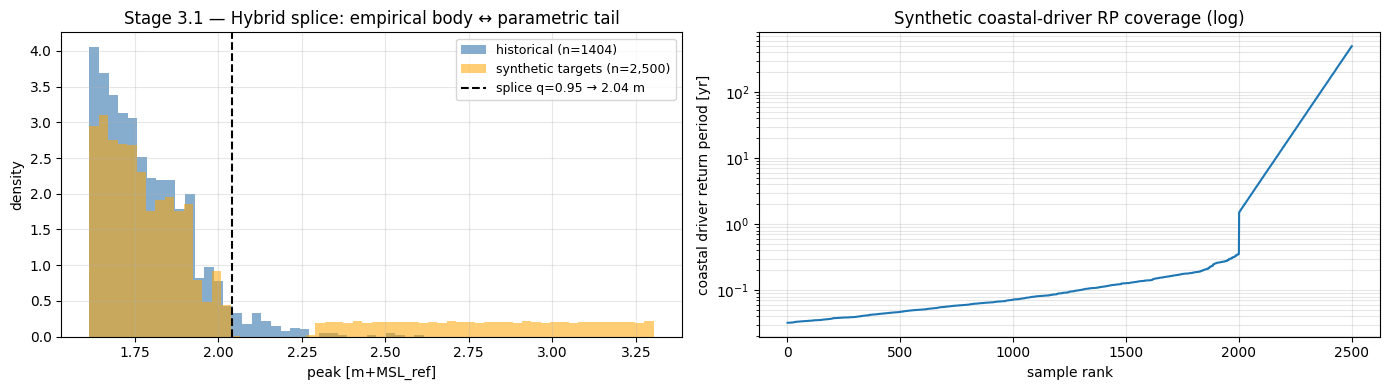

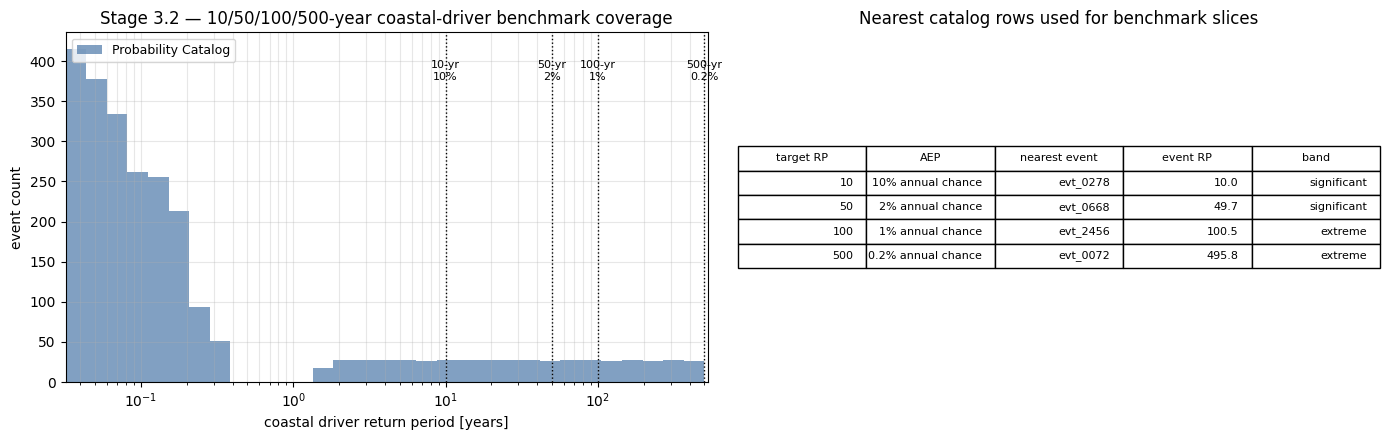

In [11]:
sampled_peaks = build_sampled_peaks(config, paths)
splice_q = config["sampling"]["hybrid_splice_quantile"]
benchmark_return_periods = config["resilience_stress_training"]["benchmark_return_period_years"]
benchmark_events = P.nearest_benchmark_events(sampled_peaks, benchmarks=benchmark_return_periods)
P.plot_hybrid_splice(historical_peaks, sampled_peaks, splice_q);
P.plot_return_period_benchmark_coverage(sampled_peaks, benchmarks=benchmark_return_periods);
display(benchmark_events[[
    "benchmark_return_period_years", "annual_chance_label", "event_id",
    "sample_rp_years", "severity_band", "probability_weight",
]].round({"sample_rp_years": 2, "probability_weight": 8}))
sampled_peaks.head()


## Stage 4 — Build event hydrographs

`design_events.build_events.hydrographs`. Cut historical storm shapes
around real peaks, normalise them, then for each synthetic peak choose a
nearest-shape template via Gaussian kernel weights with a re-use penalty.
Tail-morph stretches the time axis modestly for above-record targets.


In [12]:
artifacts = build_surge_event_artifacts(config, paths)
template_frame = artifacts["template_frame"]
summary = artifacts["member_summary"]


### 4.1 Historical template bank


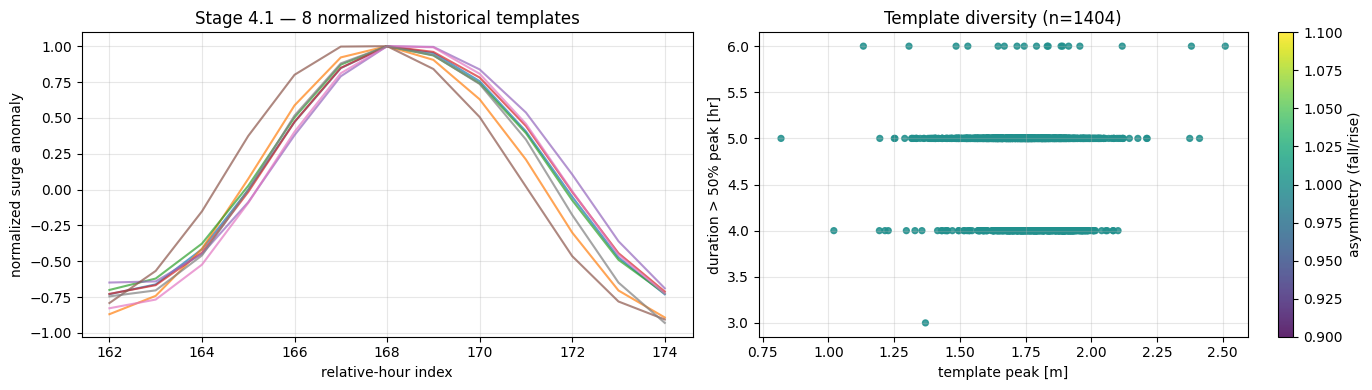

In [13]:
P.plot_template_bank(template_frame);


### 4.2 Tail-morph factor (out-of-sample peaks)


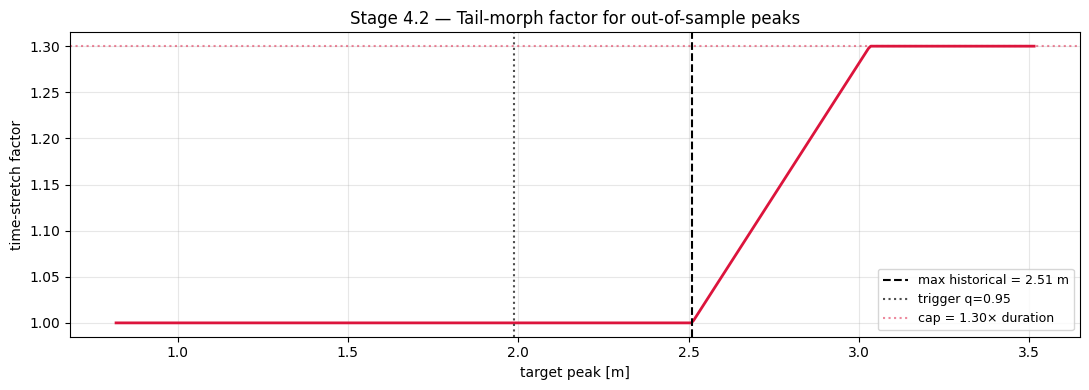

In [14]:
P.plot_tail_morph(template_frame["peak_m"].to_numpy(), config["design_events"]);


### 4.3 Template matching (kernel weights for one target)


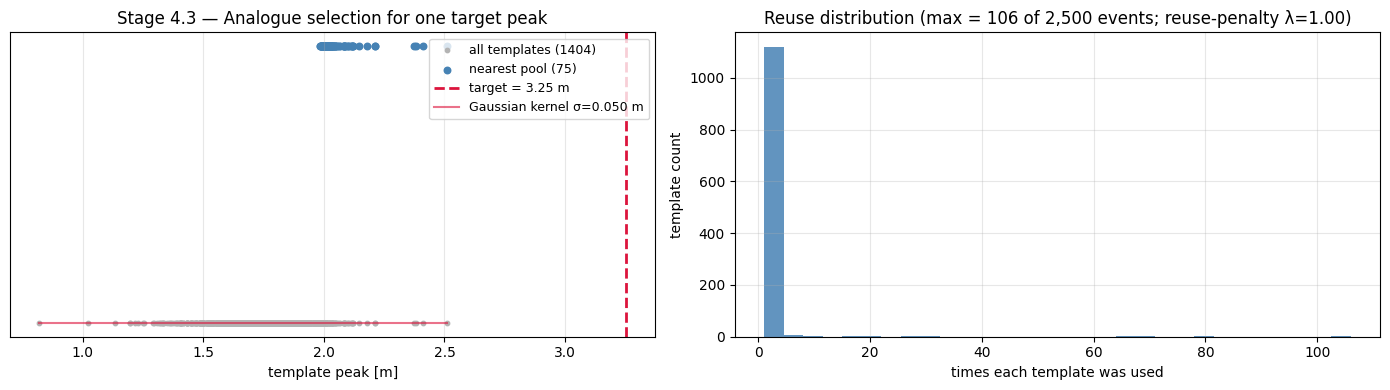

In [15]:
target = float(sampled_peaks["peak_m"].quantile(0.99))
match_settings = {**config["design_events"], **config["template_assignment"]}
P.plot_template_matching(template_frame, summary, target_peak=target, settings=match_settings);


### 4.4 Acceptance: synthetic vs historical shape descriptors


event_catalog          /home/grahamhults/projects/Flood-RM/locations/...
event_catalog_rows                                                  2500
event_catalog_audit    /home/grahamhults/projects/Flood-RM/locations/...
Name: event_catalog_outputs, dtype: object

{'event_count': 2500,
 'valid_event_count': 2500,
 'all_qc_descriptors_populated': True,
 'max_template_reuse_fraction': 0.0424,
 'tail_morph_fraction_gt_1p15': 0.1052,
 'distribution_diagnostics': {'peak': {'ks': 0.19715099715099715,
   'wasserstein': 0.22748846212558235},
  'volume': {'ks': 0.194614245014245, 'wasserstein': 1.7678589512659826},
  'duration_above_50pct_peak': {'ks': 0.13157948717948717,
   'wasserstein': 0.22638974358974365},
  'asymmetry_ratio': {'ks': 0.0, 'wasserstein': 0.0}},
 'checks': {'at_least_2500_valid_events': True,
  'tail_morph_fraction_lt_0p05': False,
  'max_template_reuse_fraction_lte_0p02': False,
  'all_qc_descriptors_populated': True},
 'passed': False,
 'scenario_name': 'base',
 'slr_offset_m': 0.0}

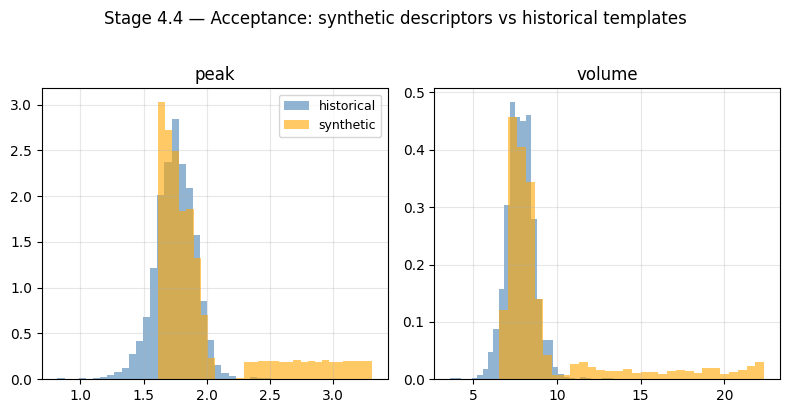

In [16]:
P.plot_acceptance_descriptors(template_frame, summary)
write_event_artifacts(paths, artifacts)
event_catalog = build_event_catalog(config, paths)
display(pd.Series({
    "event_catalog": str(paths["event_catalog_csv"]),
    "event_catalog_rows": len(event_catalog),
    "event_catalog_audit": str(paths["event_catalog_audit_json"]),
}, name="event_catalog_outputs"))
artifacts["acceptance"]


### 4.5 Sample distinct oscillatory water-level proxies


,template_id,sample_rp_years,peak,volume,duration_above_50pct_peak,asymmetry_ratio,sign_changes,roughness,oscillation_score
event_id,,,,,,,,,
evt_0726,tpl_0512,0.172904,1.909274,8.951610,5,1.0,54,86.318640,58.315932
evt_2402,tpl_0048,0.038575,1.646525,7.653349,5,1.0,54,85.982688,58.299134
evt_0917,tpl_1147,137.801922,3.079435,21.518486,7,1.0,53,110.571834,58.528592
evt_1906,tpl_1379,0.108203,1.827175,9.510336,6,1.0,55,67.539989,58.376999
evt_0977,tpl_1238,445.341068,3.284892,22.263504,7,1.0,54,111.434062,59.571703


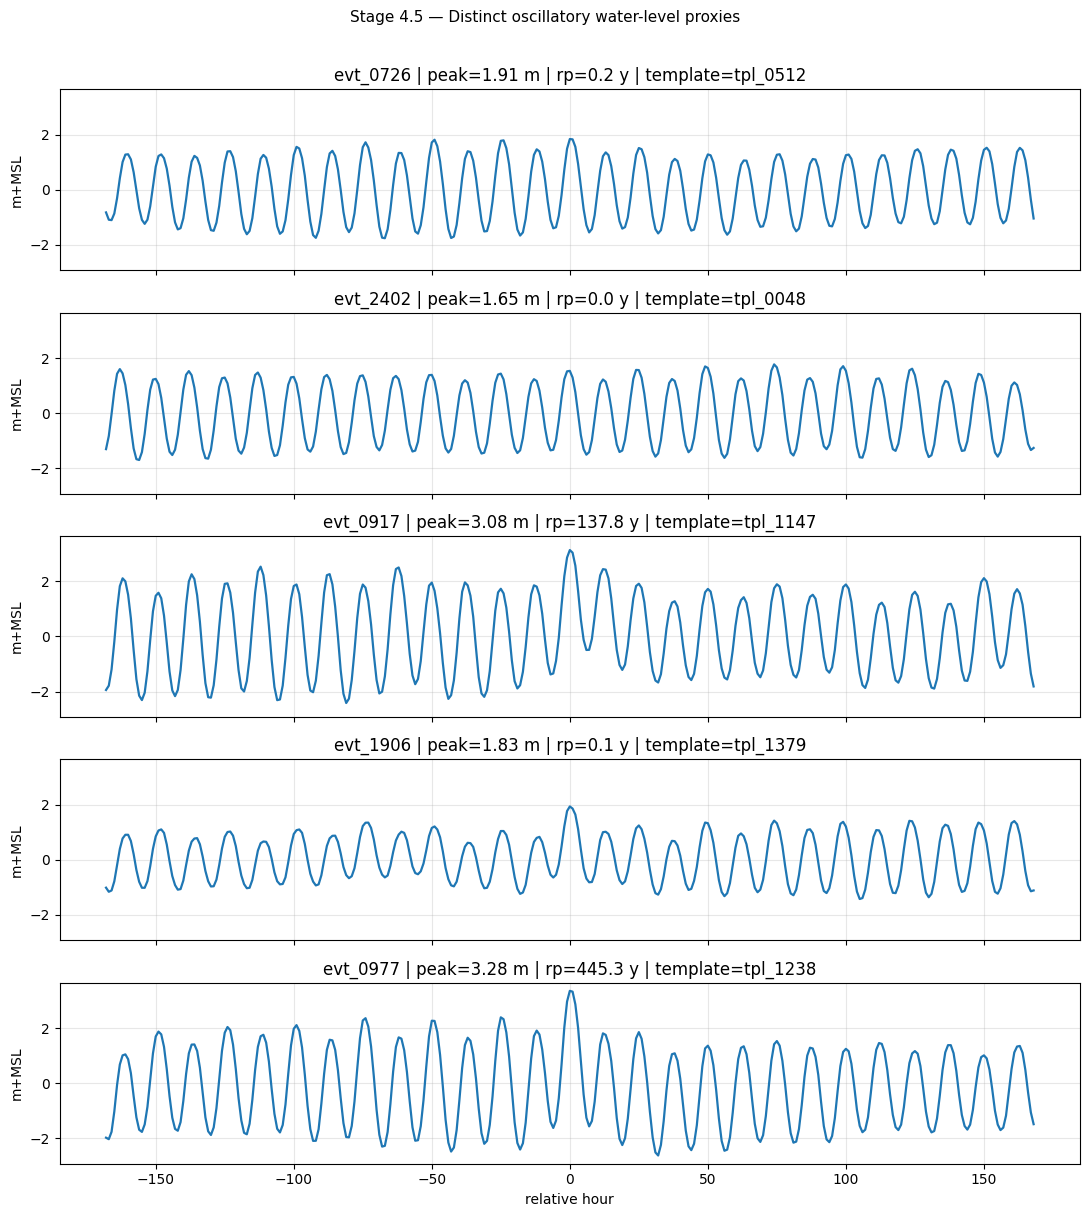

In [17]:
_, selected_proxies = P.plot_distinct_oscillatory_proxies(
    artifacts["member_dataset"],
    summary,
    template_frame,
    waterlevel,
)
display(selected_proxies)


## Stage 5 — Compound forcing pairing

The coastal event member now receives compound forcings. Rainfall comes from
direct AORC SST members, soil moisture is the 24-hour NWM antecedent state
relative to the paired rainfall member, and waves use the same historical
coastal analog as the CORA water-level template. These are auditable pairing
policies, not a claim that a full joint AEP model has been fitted.


### 5.1 Event Catalog Plan & audit gate


The plan (ADR-0005) is the one place that names which forcings are
required, which pairing policy each one uses, and where the audit JSON
lands. Display it first so the rest of Stage 5 is auditing against a
single contract.


In [18]:
plan = build_event_catalog_plan(config, paths)
plan_rows = pd.DataFrame(plan.summary_rows())
plan_rows.loc[len(plan_rows)] = {"item": "required_forcings", "value": ", ".join(plan.required_forcings)}
plan_rows.loc[len(plan_rows)] = {
    "item": "pairing_policies",
    "value": ", ".join(
        f"{f.name}:{f.pairing_policy.get('strategy', 'independent_permutation')}"
        for f in plan.forcings
    ),
}
audit = json.loads(paths["event_catalog_audit_json"].read_text(encoding="utf-8"))
plan_rows.loc[len(plan_rows)] = {"item": "wave_analog_policy", "value": plan.wave_analog_policy}
plan_rows.loc[len(plan_rows)] = {"item": "audit_passed", "value": str(audit["passed"])}
plan_rows.loc[len(plan_rows)] = {"item": "audit_issue_count", "value": str(audit["issue_count"])}
display(plan_rows)


,item,value
0,study_location,marshfield
1,scenario_name,base
2,event_summary_csv,/home/grahamhults/projects/Flood-RM/locations/...
3,event_catalog_csv,/home/grahamhults/projects/Flood-RM/locations/...
4,forcings,"rainfall, soil_moisture"
5,wave_analog_policy,same_historical_analog
6,required_forcings,"coastal, rainfall, soil_moisture"
7,pairing_policies,"rainfall:seasonal_window_permutation, soil_moi..."
8,wave_analog_policy,same_historical_analog
9,audit_passed,True


### 5.2 Pairing diagnostics per forcing


Rainfall should stay within the configured seasonal window. Soil moisture
should be the configured antecedent lag from the paired rainfall member,
not a separate seasonal shuffle. The plotting helper dispatches by the
recorded policy so the diagnostic matches the forcing semantics.


,forcing,policy,paired_rows,unique_members,unique_member_days,in_window_rows,in_window_fraction,median_gap_days,p90_gap_days,max_gap_days,max_member_reuse,p95_member_reuse,reference_rows,configured_lag_hours,median_lag_hours,min_lag_hours,max_lag_hours,on_lag_rows,on_lag_fraction
0,rainfall,seasonal_window_permutation,2500,433.0,251.0,2500.0,1.0,23.0,41.0,45.0,18.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,soil_moisture,antecedent_to_forcing,2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2500.0,24.0,24.0,24.0,24.0,2500.0,1.0


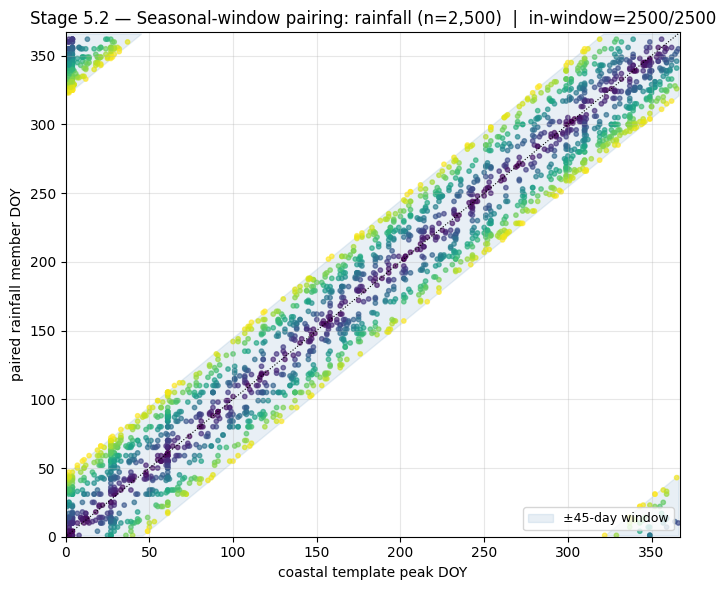

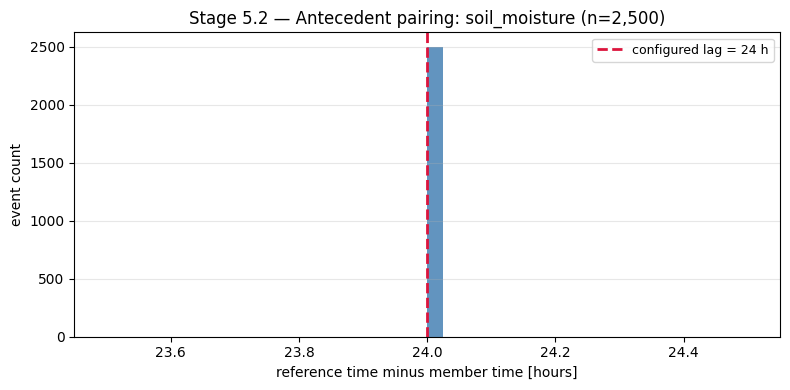

In [19]:
pairing_policies = {forcing.name: forcing.pairing_policy for forcing in plan.forcings}
pairing_summary = P.forcing_pairing_diagnostics(
    event_catalog,
    policies=pairing_policies,
)
display(pairing_summary.round(3))
for forcing_plan in plan.forcings:
    P.plot_configured_pairing(
        event_catalog,
        forcing_plan.name,
        policy=forcing_plan.pairing_policy,
    );


### 5.3 Wave same-analog audit

Wave forcing is not independently sampled. SnapWave metadata should point to
the same historical coastal analog used for the water-level hydrograph.


In [20]:
wave_analog_summary = P.wave_analog_diagnostics(event_catalog)
display(wave_analog_summary)


,forcing,policy,paired_rows,missing_rows,same_analog_rows
0,coastal_waves,same_historical_analog,2500,0,2500


### 5.4 Forcing marginal and joint comparison

These diagnostics compare the paired catalog back to the source forcing-member
tables. Marginal plots ask whether selected rainfall and antecedent soil states
look like the available member body. Joint plots show which forcing values were
paired with each Coastal Driver Return Period. They are audits of the pairing
policy, not proof of a fitted joint AEP model.


,forcing,member_id,member_value,selected_count,selected_probability_mass,value_column
253,rainfall,rainfall_marshfield_72h_rank0254,79.662501,18,0.006519,mean_precip_mm
313,rainfall,rainfall_marshfield_72h_rank0314,73.525894,16,0.005781,mean_precip_mm
209,rainfall,rainfall_marshfield_72h_rank0210,83.532144,18,0.005728,mean_precip_mm
264,rainfall,rainfall_marshfield_72h_rank0265,78.485715,14,0.005724,mean_precip_mm
229,rainfall,rainfall_marshfield_72h_rank0230,81.579466,14,0.005473,mean_precip_mm
50,rainfall,rainfall_marshfield_72h_rank0051,129.943752,15,0.005356,mean_precip_mm
342,rainfall,rainfall_marshfield_72h_rank0343,70.374108,11,0.005225,mean_precip_mm
274,rainfall,rainfall_marshfield_72h_rank0275,77.324108,11,0.005225,mean_precip_mm
301,rainfall,rainfall_marshfield_72h_rank0302,74.570537,11,0.005225,mean_precip_mm
116,rainfall,rainfall_marshfield_72h_rank0117,105.655359,12,0.005149,mean_precip_mm


,forcing,member_id,member_value,selected_count,selected_probability_mass,value_column
122713,soil_moisture,soil_moisture_20210130T060000,0.265,18,0.006519,soil_moisture_mean
8375,soil_moisture,soil_moisture_19811214T000000,0.276,16,0.005781,soil_moisture_mean
122205,soil_moisture,soil_moisture_20201127T180000,0.274,18,0.005728,soil_moisture_mean
108123,soil_moisture,soil_moisture_20160202T120000,0.265,14,0.005724,soil_moisture_mean
93489,soil_moisture,soil_moisture_20110130T060000,0.262,14,0.005473,soil_moisture_mean
87231,soil_moisture,soil_moisture_20081209T000000,0.274,15,0.005356,soil_moisture_mean
26979,soil_moisture,soil_moisture_19880426T120000,0.260,11,0.005225,soil_moisture_mean
88283,soil_moisture,soil_moisture_20090419T120000,0.266,11,0.005225,soil_moisture_mean
107333,soil_moisture,soil_moisture_20151026T180000,0.248,11,0.005225,soil_moisture_mean
3301,soil_moisture,soil_moisture_19800319T180000,0.291,12,0.005149,soil_moisture_mean


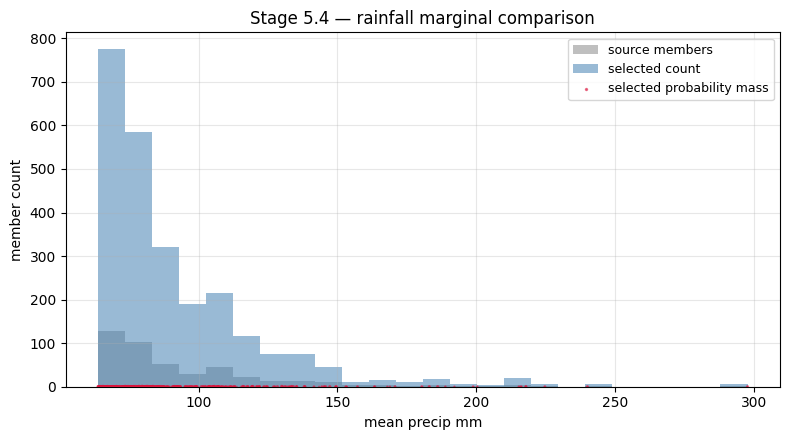

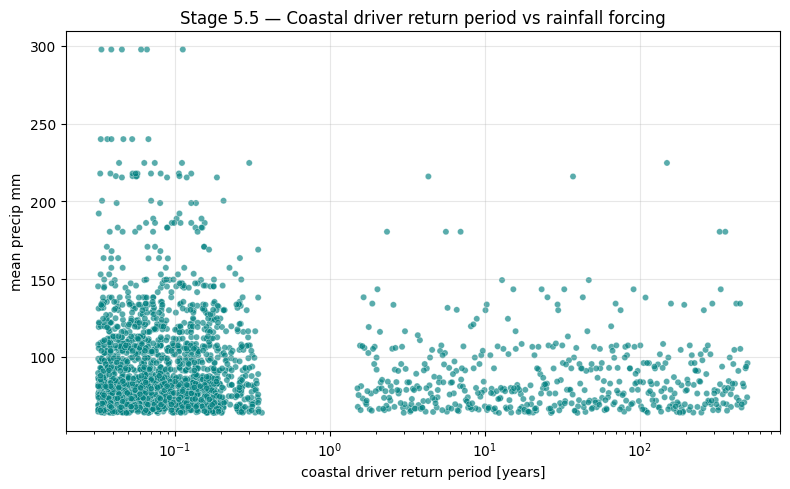

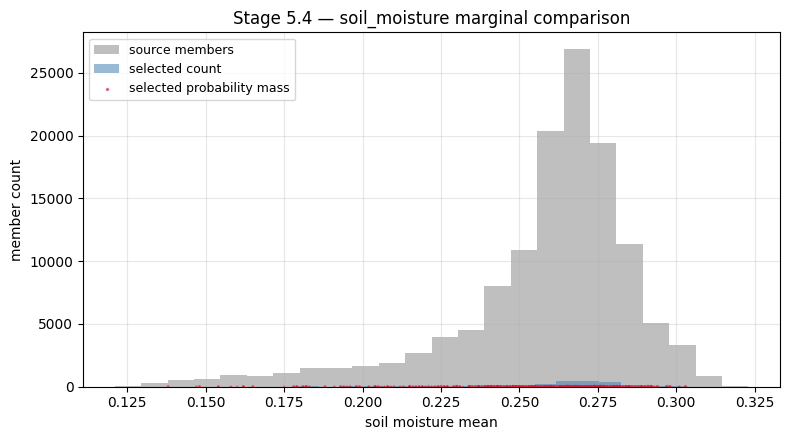

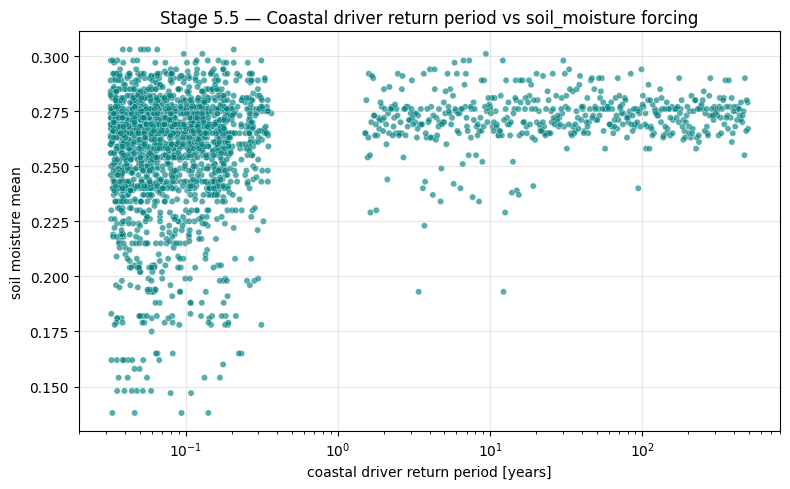

In [21]:
soil_moisture_members = pd.read_csv(paths["nwm_soil_moisture_csv"])

for forcing_name, members in [
    ("rainfall", rainfall_members),
    ("soil_moisture", soil_moisture_members),
]:
    selection = P.forcing_selection_frame(event_catalog, members, forcing_name)
    display(
        selection.sort_values("selected_probability_mass", ascending=False)
        .head(10)[[
            "forcing", "member_id", "member_value",
            "selected_count", "selected_probability_mass", "value_column",
        ]]
    )
    P.plot_forcing_marginal_comparison(event_catalog, members, forcing_name);
    P.plot_coastal_forcing_joint(event_catalog, members, forcing_name);


### 5.5 Sensitivity — independent vs seasonal permutation


The methodology keeps `independent_permutation` as a baseline sensitivity
case. We rebuild rainfall pairing under that strategy in memory (without
overwriting the catalog) and overlay the two policies. The seasonal-window
panel should hug the diagonal; the independent panel should scatter
freely. The visible difference is the "what seasonal pairing buys you"
diagnostic.


,policy,paired_rows,unique_members,in_window_rows,in_window_fraction,median_gap_days,p90_gap_days,max_gap_days,max_member_reuse
0,seasonal_window_permutation,2500,433,2500,1.000,23.0,41.0,45.0,18
1,independent_permutation,2500,440,596,0.238,96.0,166.0,183.0,6


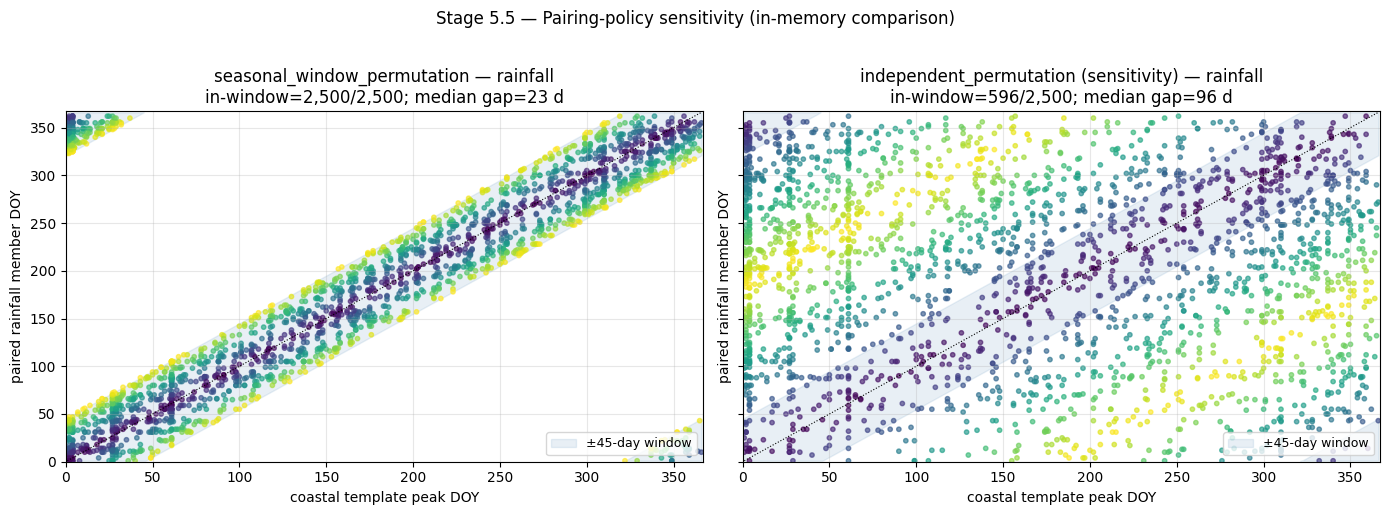

In [22]:
# Rebuild rainfall under independent_permutation in memory only.
rainfall_plan = plan.forcing("rainfall")
catalog_independent = rebuild_forcing_pairing(
    event_catalog,
    rainfall_plan.member_path,
    "rainfall",
    {"strategy": "independent_permutation", "seed": 42},
)
pairing_sensitivity = pd.concat(
    [
        P.seasonal_pairing_diagnostics(
            event_catalog,
            "rainfall",
            window_days=rainfall_plan.pairing_policy.get("window_days"),
        ).assign(policy="seasonal_window_permutation"),
        P.seasonal_pairing_diagnostics(
            catalog_independent,
            "rainfall",
            window_days=rainfall_plan.pairing_policy.get("window_days"),
        ).assign(policy="independent_permutation"),
    ],
    ignore_index=True,
)
display(pairing_sensitivity[[
    "policy", "paired_rows", "unique_members", "in_window_rows",
    "in_window_fraction", "median_gap_days", "p90_gap_days",
    "max_gap_days", "max_member_reuse",
]].round(3))
P.plot_independent_vs_seasonal(
    event_catalog,
    catalog_independent,
    "rainfall",
    window_days=rainfall_plan.pairing_policy.get("window_days"),
);


## Stage 6 — Probability catalog and resilience stress/training set

These plots answer different questions. The Probability Catalog should be
mild-dominated by probability mass because frequent non-damaging coastal-driver
conditions are common. The Resilience Stress/Training Set should not be
mild-dominated because it is the high-fidelity SFINCS and dynamic-microgrid
budget. Keep both views visible so stakeholders do not mistake natural
probability mass for simulation-budget priority.


### 6.1 Probability Catalog severity ranges

This plot is intentionally probability-weighted. It explains annualized risk
accounting, not where the expensive SFINCS runs should be spent. The configured
coastal-driver return-period ranges are shown first so the mild/common/
significant/rare/extreme labels are concrete.


,severity_band,coastal_driver_return_period_range,annual_chance_range
0,mild,0 to <2 yr,> 50%
1,common,2 to <10 yr,> 10% to <= 50%
2,significant,10 to <50 yr,> 2% to <= 10%
3,rare,50 to <100 yr,> 1% to <= 2%
4,extreme,100 to <500 yr,> 0.2% to <= 1%
5,beyond_design,>= 500 yr,<= 0.2%


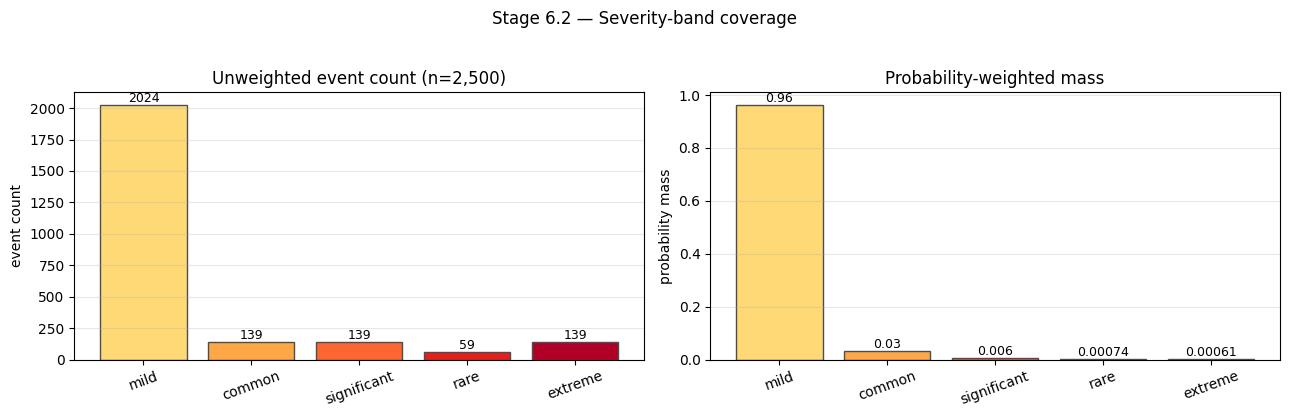

In [23]:
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["coastal_driver_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "coastal_driver_return_period_range", "annual_chance_range"]])
P.plot_severity_bands(event_catalog);


### 6.2 Resilience Stress/Training Set

This subset is not a replacement for the weighted Probability Catalog. It is
the SFINCS/DNMG contingency-operation budget: nearest 10%, 2%, 1%, and
0.2% annual-chance coastal-driver benchmarks, rare coastal drivers,
operationally severe plausible rainfall dependence, wet antecedent soil
states, several high-magnitude historical compound pairs, and later
near-threshold grid-response cases once SFINCS and power metrics have been
evaluated. Its figures should make clear that the high-fidelity budget is
no longer mostly mild events.


stress_training_rows                                                     500
mild_rows                                                                 24
mild_fraction                                                          0.048
stress_training_csv        /home/grahamhults/projects/Flood-RM/locations/...
compound_pairing_policy            operationally_severe_plausible_dependence
Name: resilience_stress_training, dtype: object

,event_id,sample_rp_years,severity_band,probability_weight,benchmark_return_period_years,selection_reason,compound_pairing_role,scenario_timing_edge_case,rainfall_metric_mm
499,evt_0072,495.84,extreme,0.000002,500,nearest_0p2pct_annual_chance_coastal_driver;ta...,high_rainfall_cooccurrence,rainfall-coincident,180.424110
361,evt_2456,100.47,extreme,0.000009,100,nearest_1pct_annual_chance_coastal_driver;tail...,high_rainfall_cooccurrence,rainfall-coincident,224.723218
301,evt_0668,49.68,significant,0.000018,50,nearest_2pct_annual_chance_coastal_driver;tail...,high_rainfall_cooccurrence,rainfall-coincident,180.424110
163,evt_0278,10.01,significant,0.000087,10,nearest_10pct_annual_chance_coastal_driver;tai...,rainfall_after_coastal,rainfall-after-coastal,224.723218
498,evt_1398,492.96,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver,rainfall_before_coastal,rainfall-before-coastal,180.424110
497,evt_1582,485.37,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver,rainfall_after_coastal,rainfall-after-coastal,180.424110
496,evt_1251,481.72,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver,wet_soil_high_rainfall,wet-soil-high-rain,180.424110
495,evt_1966,472.41,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver;wet_anteceden...,high_rainfall_cooccurrence,rainfall-coincident,180.424110
494,evt_2318,469.15,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver,wet_soil_high_rainfall,wet-soil-high-rain,180.424110
493,evt_2428,463.19,extreme,0.000002,NaN,tail_or_benchmark_coastal_driver,rainfall_after_coastal,rainfall-after-coastal,180.424110


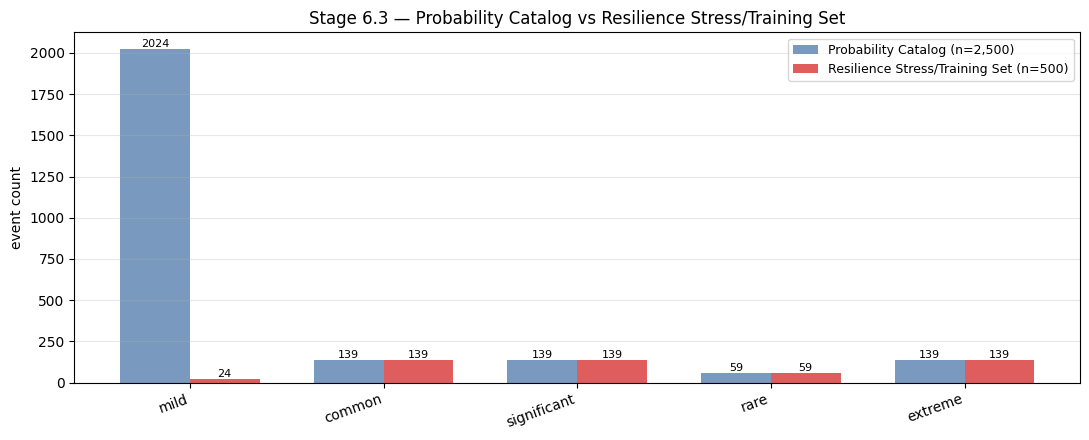

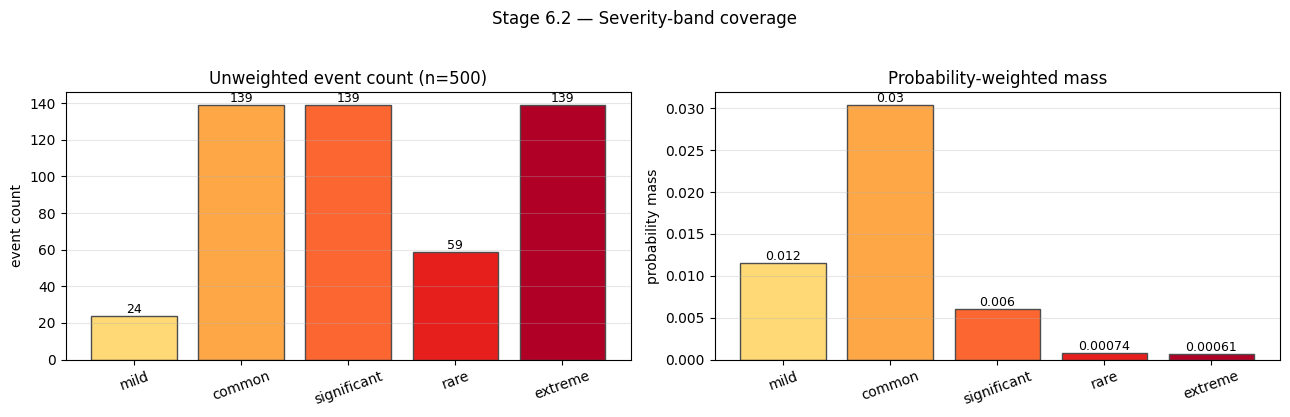

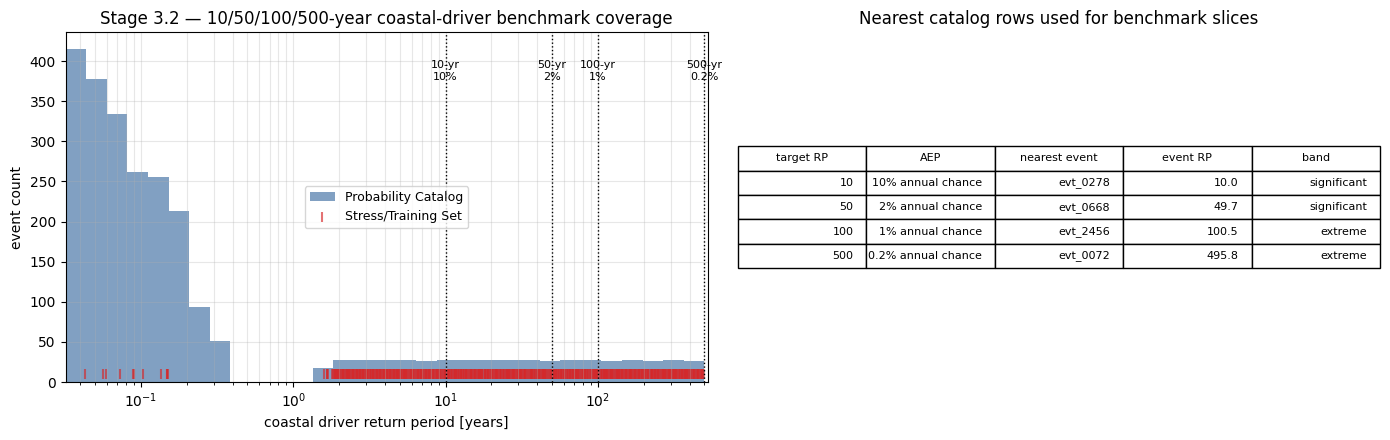

In [24]:
stress_training_catalog = select_resilience_stress_training_set(
    event_catalog,
    rainfall_members=rainfall_members,
    soil_moisture_members=soil_moisture_members,
    config=config,
)
paths["resilience_stress_training_catalog_csv"].parent.mkdir(parents=True, exist_ok=True)
stress_training_catalog.to_csv(paths["resilience_stress_training_catalog_csv"], index=False)

P.plot_catalog_set_severity_comparison(event_catalog, stress_training_catalog);
P.plot_severity_bands(stress_training_catalog);
P.plot_return_period_benchmark_coverage(
    event_catalog,
    stress_catalog=stress_training_catalog,
    benchmarks=benchmark_return_periods,
);

stress_summary = pd.Series({
    "stress_training_rows": len(stress_training_catalog),
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
    "compound_pairing_policy": stress_training_catalog.get("compound_pairing_policy", pd.Series([pd.NA])).dropna().iloc[0]
    if "compound_pairing_policy" in stress_training_catalog and stress_training_catalog["compound_pairing_policy"].notna().any() else pd.NA,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.assign(
    has_benchmark=stress_training_catalog["benchmark_return_period_years"].notna(),
    is_mild=stress_training_catalog["severity_band"].eq("mild"),
).sort_values(
    ["has_benchmark", "is_mild", "sample_rp_years"],
    ascending=[False, True, False],
)
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "probability_weight",
    "benchmark_return_period_years", "selection_reason",
    "compound_pairing_role", "scenario_timing_edge_case", "rainfall_metric_mm",
]].head(16).round({"sample_rp_years": 2, "probability_weight": 8}))


### 6.3 Event Catalog row preview


Every row carries the source, member id, pairing policy, sampling region,
sampling weight, wave analog metadata, and infiltration treatment required
by the methodology audit rules. Showing a slice here makes the recorded
recipe explicit before SFINCS consumes it.


In [25]:
catalog_preview_columns = [
    "event_id", "scenario_name", "sample_rp_years", "severity_band", "sampling_region", "sampling_weight", "probability_weight",
    "coastal_source", "coastal_member_id", "coastal_analog_id", "snapwave_pairing_policy",
    "rainfall_source", "rainfall_member_id", "rainfall_pairing_policy", "rainfall_pairing_window_days",
    "soil_moisture_source", "soil_moisture_member_id", "soil_moisture_pairing_policy",
    "soil_moisture_pairing_reference_time", "soil_moisture_pairing_lag_hours",
    "infiltration_treatment",
]
present_columns = [column for column in catalog_preview_columns if column in event_catalog.columns]
display(event_catalog[present_columns].head(5))
display(pd.Series({
    "audit_passed": audit["passed"],
    "audit_issues": audit["issue_count"],
    "catalog_csv": str(paths["event_catalog_csv"]),
    "audit_json": str(paths["event_catalog_audit_json"]),
}, name="event_catalog_audit"))


,event_id,scenario_name,sample_rp_years,severity_band,sampling_region,sampling_weight,probability_weight,coastal_source,coastal_member_id,coastal_analog_id,...,rainfall_source,rainfall_member_id,rainfall_pairing_policy,rainfall_pairing_window_days,soil_moisture_source,soil_moisture_member_id,soil_moisture_pairing_policy,soil_moisture_pairing_reference_time,soil_moisture_pairing_lag_hours,infiltration_treatment
0,evt_0001,base,0.147906,mild,body,1.1875,0.000475,cora,evt_0001,tpl_0194,...,aorc_sst,rainfall_marshfield_72h_rank0027,seasonal_window_permutation,45,nwm,soil_moisture_20090910T000000,antecedent_to_forcing,2009-09-11T00:00:00,24.0,none
1,evt_0002,base,0.044461,mild,body,1.1875,0.000475,cora,evt_0002,tpl_1083,...,aorc_sst,rainfall_marshfield_72h_rank0368,seasonal_window_permutation,45,nwm,soil_moisture_19870227T120000,antecedent_to_forcing,1987-02-28T12:00:00,24.0,none
2,evt_0003,base,7.776219,common,tail,0.2500,0.000112,cora,evt_0003,tpl_1238,...,aorc_sst,rainfall_marshfield_72h_rank0306,seasonal_window_permutation,45,nwm,soil_moisture_20221221T060000,antecedent_to_forcing,2022-12-22T06:00:00,24.0,none
3,evt_0004,base,0.274365,mild,body,1.1875,0.000475,cora,evt_0004,tpl_0159,...,aorc_sst,rainfall_marshfield_72h_rank0170,seasonal_window_permutation,45,nwm,soil_moisture_19900805T000000,antecedent_to_forcing,1990-08-06T00:00:00,24.0,none
4,evt_0005,base,0.138144,mild,body,1.1875,0.000475,cora,evt_0005,tpl_0193,...,aorc_sst,rainfall_marshfield_72h_rank0170,seasonal_window_permutation,45,nwm,soil_moisture_19900805T000000,antecedent_to_forcing,1990-08-06T00:00:00,24.0,none


audit_passed                                                 True
audit_issues                                                    0
catalog_csv     /home/grahamhults/projects/Flood-RM/locations/...
audit_json      /home/grahamhults/projects/Flood-RM/locations/...
Name: event_catalog_audit, dtype: object

## Stage 7 — SLR scenario comparison

Storm shape and anomaly magnitude are scenario-invariant; only the MSL
offset changes. Catalog + sampled peaks are scenario-independent. Only
`build_event_members` is re-run per scenario.


In [26]:
# Build the surge_event_members.nc for each non-base MSL-shift scenario.
# Storm shape and anomaly magnitude are reused from base; build_paths(...,
# scenario=name) swaps the events_<name>/ output folder, and the MSL offset
# is applied via _apply_msl_shift inside build_surge_event_artifacts.
from design_events.config import build_paths
non_base_scenarios = [s for s in config.get("scenarios", {}) if s != "base"]
for scenario_name in non_base_scenarios:
    scen_paths = build_paths(config, scenario=scenario_name)
    scen_artifacts = build_surge_event_artifacts(config, scen_paths)
    write_event_artifacts(scen_paths, scen_artifacts)
    print(
        f"wrote {scen_paths['event_members_nc']}  "
        f"(offset={scen_paths['scenario']['slr_offset_m']:+.2f} m)"
    )


wrote /home/grahamhults/projects/Flood-RM/locations/marshfield/data/event_catalog/events_noaa_int_2050/surge_event_members.nc  (offset=+0.30 m)
wrote /home/grahamhults/projects/Flood-RM/locations/marshfield/data/event_catalog/events_noaa_int_2100/surge_event_members.nc  (offset=+1.10 m)


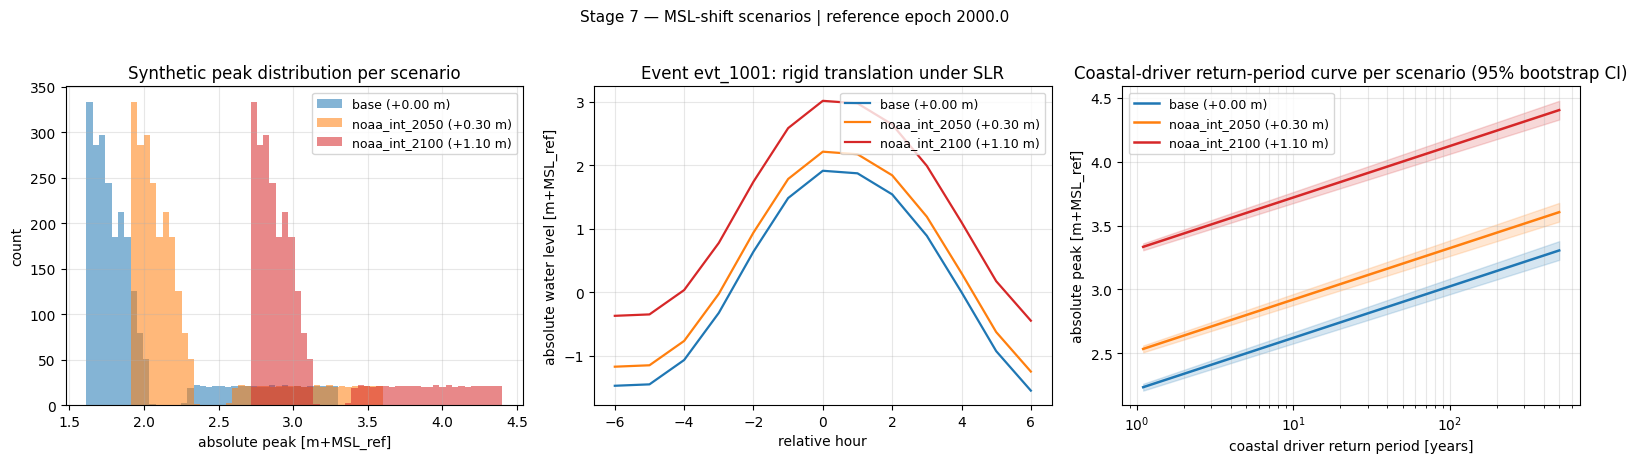

In [27]:
import xarray as xr
scenario_names = ["base", "noaa_int_2050", "noaa_int_2100"]
scenario_colors = {"base": "#1f77b4", "noaa_int_2050": "#ff7f0e", "noaa_int_2100": "#d62728"}

def events_dir(outputs_root, scenario):
    return outputs_root / ("events" if scenario == "base" else f"events_{scenario}")

scenario_datasets = {
    name: xr.open_dataset(events_dir(paths["outputs_root"], name) / "surge_event_members.nc")
    for name in scenario_names
}
try:
    P.plot_msl_shift_scenario_comparison(
        scenario_datasets,
        pd.read_csv(paths["marginal_rps_ci_csv"]),
        pd.read_csv(paths["marginal_params_csv"], index_col=0),
        scenario_colors=scenario_colors,
    );
finally:
    for ds in scenario_datasets.values():
        ds.close()


## Stage 8 — Hand off to SFINCS

Hand off both catalog views. The full Probability Catalog supports annualized
weighted summaries after SFINCS response evaluation. The Resilience
Stress/Training Set is the recommended high-fidelity run budget for dynamic
microgridding because it concentrates on threshold-changing, compound, and rare
states while keeping provenance back to the weighted catalog.


In [28]:
design_inputs, member_ds = read_design_inputs(paths["outputs_root"])
event_row = design_inputs.iloc[0]
forcing = build_event_timeseries(event_row, surge_event_members=member_ds)
sfincs_ready = pd.DataFrame({
    "relative_hour": forcing["h"].index,
    "coastal_water_level_msl": forcing["h"].values,
})
sfincs_ready.head(12)


,relative_hour,coastal_water_level_msl
0,-72,0.964087
1,-71,0.262014
2,-70,-0.532039
3,-69,-1.117007
4,-68,-1.404614
5,-67,-1.411737
6,-66,-1.097604
7,-65,-0.430340
8,-64,0.333357
9,-63,0.894985
